In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load Data
df = pd.read_csv('../data/preprocessed/final_master_training_set.csv')


In [2]:


# Train/Test Split 
# Using a fixed random_state for reproducibility
train, test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['classification'])
print(f"Training shape: {train.shape}")
print(f"Testing shape: {test.shape}")




Training shape: (5455, 2)
Testing shape: (1364, 2)


In [3]:

# Vectorization
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
train_vectors = vectorizer.fit_transform(train['text_features'])
test_vectors = vectorizer.transform(test['text_features'])



In [4]:


# Model Training (Logistic Regression)
# 'class_weight=balanced' is crucial since have many more mitigation policies
clf = LogisticRegression(class_weight='balanced', max_iter=1000)
clf.fit(train_vectors, train['classification'])



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [5]:


# Prediction
test['pred'] = clf.predict(test_vectors)


In [6]:

# Evaluation Metrics
print(f"Accuracy: {metrics.accuracy_score(test['classification'], test['pred']):.4f}")
print(f"Macro Precision: {metrics.precision_score(test['classification'], test['pred'], average='macro'):.4f}")
print(f"Macro Recall: {metrics.recall_score(test['classification'], test['pred'], average='macro'):.4f}")


Accuracy: 0.9135
Macro Precision: 0.7627
Macro Recall: 0.8379


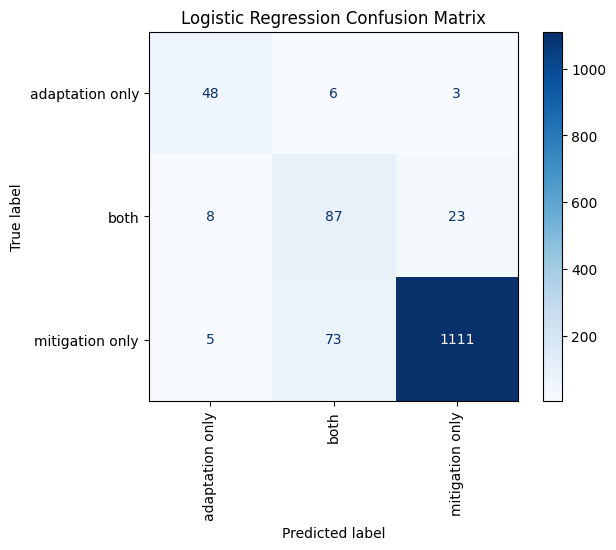

In [7]:

# Visualization
cm = confusion_matrix(test['classification'], test['pred'], labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [8]:
# --- LOGISTIC REGRESSION TEST PREDICTOR ---
def test_logreg_model(sample_text):
    # Transform text using the TfidfVectorizer from this notebook
    sample_vec = vectorizer.transform([sample_text])
    
    # Predict
    prediction = clf.predict(sample_vec)[0]
    
    # Get specific probabilities
    probs = clf.predict_proba(sample_vec)[0]
    conf = f"{max(probs)*100:.1f}%"
    
    print(f"--- Logistic Regression Results ---")
    print(f"Text: {sample_text[:100]}...")
    print(f"Label: {prediction}")
    print(f"Confidence: {conf}")

# Use the same test string as the other notebook
test_string = "Implementing coastal barriers and sea walls to protect from rising sea levels."
test_logreg_model(test_string)

--- Logistic Regression Results ---
Text: Implementing coastal barriers and sea walls to protect from rising sea levels....
Label: adaptation only
Confidence: 72.2%


In [9]:
# The 2026 Stress Test Suite
test_policies = [
    "Construction of regional seed banks to preserve indigenous crop varieties against increasing drought frequency.",
    "Mandatory retrofitting of industrial furnaces to utilize green hydrogen instead of liquid natural gas.",
    "Restoration of coastal mangrove forests to sequester carbon and provide natural storm surge protection.",
    "Upgrading the national railway grid to withstand extreme heat buckling while increasing electric cargo capacity.",
    "The Ministry of Environment issued a general executive decree regarding the 2013 planning framework for national development."
]

print(f"Model being tested: {type(clf).__name__}\n")

for i, policy in enumerate(test_policies):
    # Vectorize and Predict (Matches your specific notebook's vectorizer)
    vec = vectorizer.transform([policy])
    label = clf.predict(vec)[0]
    
    # Try to get probability for 'Confidence'
    try:
        prob = clf.predict_proba(vec).max()
        confidence = f"{prob:.2%}"
    except:
        confidence = "N/A"
        
    print(f"Test {i+1}: {label} ({confidence})")
    print(f"Text: {policy[:80]}...")
    print("-" * 20)

Model being tested: LogisticRegression

Test 1: mitigation only (46.58%)
Text: Construction of regional seed banks to preserve indigenous crop varieties agains...
--------------------
Test 2: mitigation only (79.40%)
Text: Mandatory retrofitting of industrial furnaces to utilize green hydrogen instead ...
--------------------
Test 3: adaptation only (55.20%)
Text: Restoration of coastal mangrove forests to sequester carbon and provide natural ...
--------------------
Test 4: adaptation only (43.68%)
Text: Upgrading the national railway grid to withstand extreme heat buckling while inc...
--------------------
Test 5: mitigation only (48.09%)
Text: The Ministry of Environment issued a general executive decree regarding the 2013...
--------------------


In [ ]:
import joblib

# Save the model
joblib.dump(clf, 'logreg_model.joblib')
joblib.dump(vectorizer, 'logreg_vectorizer.joblib')

['logreg_vectorizer.joblib']